extract marker counts and morphological information from all the cells in your images

In [1]:
# import required packages
import os
import warnings
import pandas as pd
from alpineer import io_utils
from skimage import io
from ark.segmentation import marker_quantification, segmentation_utils
from ark.utils import deepcell_service_utils, example_dataset, plot_utils

## 0: Set root directory and download example dataset

Here we are using the example data located in `/data/example_dataset/input_data`. To modify this notebook to run using your own data, simply change `base_dir` to point to your own sub-directory within the data folder.

* `base_dir`: the path to all of your imaging data. This directory will contain all of the data generated by this notebook.

In [2]:
import logging
logging.basicConfig(level=logging.DEBUG,filename='post_segmentation.log', filemode='w', format='%(name)s - %(asctime)s - %(message)s')
# set up the base directory
base_dir = "../../"

If you would like to test the features in Ark with an example dataset, run the cell below. It will download a dataset consisting of 11 FOVs with 22 channels. You may find more information about the example dataset in the [README](../README.md#example-dataset).

If you are using your own data, skip the cell below.

* `overwrite_existing`: If set to `False`, it will not overwrite existing data in the `data/example_dataset`. Recommended leaving as `True` if you are doing a clean run of the `ark` pipeline using this dataset from the start. If you already have the dataset downloaded, set to `False`.

## 1: set file paths and parameters

### All data, images, files, etc. must be placed in the 'data' directory, and referenced via '../data/path_to_your_data'

If you're interested in directly interfacing with Google Drive, consult the documentation [here](https://ark-analysis.readthedocs.io/en/latest/_rtd/google_docs_usage.html).

In [3]:
# set up file paths

tiff_dir = os.path.join(base_dir, "Img_Denoised")

cell_table_dir = os.path.join(base_dir, "segmentation/cell_table_Denoised")

deepcell_input_dir = os.path.join(base_dir, "segmentation/deepcell_input_Denoised")

deepcell_output_dir = os.path.join(base_dir, "segmentation/deepcell_output_Denoised")
deepcell_visualization_dir = os.path.join(base_dir, "segmentation/deepcell_visualization")

In [4]:
# create directories if do not exist
for directory in [cell_table_dir, deepcell_input_dir, deepcell_output_dir, deepcell_visualization_dir]:
    if not os.path.exists(directory):
        os.makedirs(directory)

In [5]:
# validate paths
io_utils.validate_paths([base_dir,
                         tiff_dir,
                         deepcell_input_dir,
                         deepcell_output_dir,
                         cell_table_dir,
                         deepcell_visualization_dir
                         ])

### Compute and filter fov paths

In [27]:
# either get all fovs in the folder...
fovs = io_utils.list_folders(tiff_dir)
'''
# some of the images was not possible to process with Mesmer, so consider only the images that have a valid segmentation
Leap_ID_segmented = pd.read_csv( os.path.join(base_dir, 'segmentation/LeapID_segmented.csv'))
fovs = [*set(Leap_ID_segmented.Leap_ID)&set(fovs)]
'''
#needs to be updated

"\n# some of the images was not possible to process with Mesmer, so consider only the images that have a valid segmentation\nLeap_ID_segmented = pd.read_csv( os.path.join(base_dir, 'segmentation/LeapID_segmented.csv'))\nfovs = [*set(Leap_ID_segmented.Leap_ID)&set(fovs)]\n"

In [39]:
# either get all fovs in the folder...
fovs = io_utils.list_folders(tiff_dir)
len(sorted(fovs))

701

In [14]:
io_utils.list_folders('../../segmentation/')

['deepcell_input_Denoised',
 'cell_table',
 'deepcell_output',
 'cell_table_Denoised',
 'deepcell_output_Denoised',
 'deepcell_visualization',
 'deepcell_input']

### We can then save the segmented mask overlaid on the imaging data

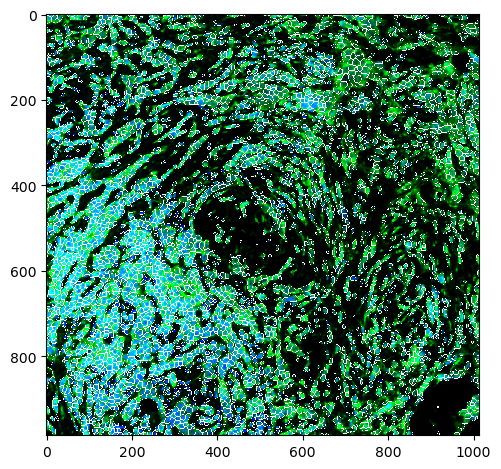

In [10]:
# display the channel overlay for a fov, useful for quick verification
warnings.simplefilter("ignore")

fov_to_display = io_utils.remove_file_extensions([fovs[0]])[0]

fov_overlay = plot_utils.create_overlay(
    fov=fov_to_display,
    segmentation_dir=deepcell_output_dir,
    data_dir=deepcell_input_dir,
    img_overlay_chans=['nuclear_channel', 'membrane_channel'],
    seg_overlay_comp='whole_cell'
)

_ = io.imshow(fov_overlay)

In [74]:

fovs = pd.Series(os.listdir(deepcell_output_dir))
#fovs = fovs[fovs.str.endswith('.tiff')].str.split('_').str[:2].str.join('_').to_list()
#fovs = ['Leap036_9']
fovs = fovs[fovs.str.endswith('.tiff')].str.rstrip('_nuclear.tiff').str.rstrip('_whole_cell.tiff')


In [75]:
# save the overlaid segmentation labels for each fov (these will not display, but will save in viz_dir)
segmentation_utils.save_segmentation_labels(
    segmentation_dir=deepcell_output_dir,
    data_dir=deepcell_input_dir,
    output_dir=deepcell_visualization_dir,
    fovs=io_utils.remove_file_extensions(fovs),
    channels=['nuclear_channel', 'membrane_channel']
)

### Afterwards, we can generate expression matrices from the labeling + imaging data

In [40]:
# set to True to add nuclear cell properties to the expression matrix
nuclear_counts = True

# set to True to bypass expensive cell property calculations
# only cell label, size, and centroid will be extracted if True
fast_extraction = False

For a full list of features extracted, please refer to the cell table section of: https://ark-analysis.readthedocs.io/en/latest/_rtd/data_types.html

In [ ]:
# now extract the segmented imaging data to create normalized and transformed expression matrices
# note that if you're loading your own dataset, please make sure all the imaging data is in the same folder
# with each fov given its own folder and all fovs having the same channels
cell_table_size_normalized, cell_table_arcsinh_transformed = \
    marker_quantification.generate_cell_table(segmentation_dir=deepcell_output_dir,
                                              tiff_dir=tiff_dir,
                                              img_sub_folder=None,
                                              fovs=fovs,
                                              batch_size=20,
                                              nuclear_counts=nuclear_counts,
                                              fast_extraction=fast_extraction)

3it [02:49, 57.02s/it]

In [12]:
!ls ../phenotyping/

__pycache__  create_adata.py  phenograph  phenotyping_utils.py	pixie


In [ ]:
import sys
sys.path.append('../phenotyping//')
from phenotyping_utils import quality_control
qc_pass = quality_control(cell_table_size_normalized)
cell_table_size_normalized['qc_pass'] = qc_pass
cell_table_arcsinh_transformed['qc_pass'] = qc_pass

In [ ]:
# Set the compression level if desired, ZSTD compression can offer up to a 60-70% reduction in file size.
# NOTE: Compressed `csv` files cannot be opened in Excel. They must be uncompressed beforehand.
compression = None

# Uncomment the line below to allow for compressed `csv` files.
#compression = True#{"method": "zstd", "level": 3}

if (compression is None) or (compression ==False):
    cell_table_normalized_path = os.path.join(cell_table_dir, 'cell_table_size_normalized_Carb.csv')
    cell_table_arcsinh_path = os.path.join(cell_table_dir, 'cell_table_arcsinh_transformed_Carb.csv')
else:
    cell_table_normalized_path = os.path.join(cell_table_dir, 'cell_table_size_normalized.zstd')
    cell_table_arcsinh_path = os.path.join(cell_table_dir, 'cell_table_arcsinh_transformed.zstd')
    
    
cell_table_size_normalized.to_csv(cell_table_normalized_path,
                                   index=False)
cell_table_arcsinh_transformed.to_csv(cell_table_arcsinh_path,
                                       index=False)

In [84]:
cell_tb_labels = pd.read_csv(os.path.join(cell_table_dir, 'cell_table_size_normalized_cell_labels.csv'))

In [67]:
#cell_table_size_normalized = pd.read_csv(os.path.join(cell_table_dir, 'cell_table_size_normalized_Carb.csv'))
len(cell_table_size_normalized),len(cell_tb_labels)
#np.all(cell_tb_labels[['fov','label']].values==cell_table_size_normalized[['fov','label']].values)

(3738846, 3738846)

In [69]:
cell_tb_labels['Carboplatin'] = cell_table_size_normalized['Carboplatin']
cell_tb_labels['Carboplatin_nuclear'] = cell_table_size_normalized['Carboplatin_nuclear']

In [70]:
#cell_tb_labels.to_csv(os.path.join(cell_table_dir, 'cell_table_size_normalized_cell_labels.csv'))

In [86]:
import matplotlib.pyplot as plt
#plt.scatter(cell_tb_labels['Carboplatin_nuclear'],cell_tb_labels['Carboplatin'])
sorted(cell_tb_labels['Carboplatin'])[::-1]


[0.992613971233368,
 0.992150068283081,
 0.9319944381713868,
 0.9246303694588798,
 0.8210190137227377,
 0.8131822185751832,
 0.78674992975199,
 0.7722537300803445,
 0.7653658606789329,
 0.7584776560465495,
 0.7560232253301711,
 0.7497490692138672,
 0.7471388828607253,
 0.7441984812418619,
 0.7378858240639291,
 0.7305671467500574,
 0.7299619402204242,
 0.7259837641860499,
 0.725045424241286,
 0.7092696947929187,
 0.7090012232462565,
 0.6842017769813538,
 0.6839991092681885,
 0.6736926094430392,
 0.6689953523523667,
 0.6686888422284808,
 0.6644209258410395,
 0.6619714041736638,
 0.6612289653104895,
 0.6577818335556402,
 0.6530861101652446,
 0.6438771707040293,
 0.6431077556845582,
 0.6402895667336204,
 0.6401339636908637,
 0.6365429271351207,
 0.6247422144963191,
 0.621934829219695,
 0.6159600438298406,
 0.6140060920219916,
 0.6138961288955186,
 0.6119636346485989,
 0.6044861248561314,
 0.6007554133733114,
 0.5954557867611155,
 0.5863963593827918,
 0.5854050772530692,
 0.5824863330737965

In [71]:
fov_name = 'Leap004_9'
nuclear_file = fov_name + '_nuclear.tiff'
